# 02 - Classification
### Multiclass intrusion detection: predicting the attack label from network flow features

**Pipeline:** load cleaned data -> take a stratified working sample (hardware
constraints) -> encode/split/scale -> train 10 classifiers -> compare ->
tune the top 3 -> handle imbalance with SMOTE -> save the best model.

This notebook imports everything from `src/preprocessing.py` and
`src/utils.py` rather than redefining cleaning or plotting logic here.


## 1. Imports

In [1]:
import os
import sys
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, BaggingClassifier,
)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.base import clone
from imblearn.over_sampling import SMOTE

sys.path.insert(0, os.path.join("..", "src"))
import preprocessing as prep
import utils

utils.set_plot_style()
RANDOM_STATE = 42
PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models", "classification")
FIGURES_DIR = os.path.join("..", "reports", "figures")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


## 2. Load the cleaned dataset

This expects `data/processed/cleaned_dataset.csv`, produced by running
`01_EDA.ipynb` first.

In [2]:
clean_path = os.path.join(PROCESSED_DIR, "cleaned_dataset.csv")
if not os.path.exists(clean_path):
    raise FileNotFoundError(
        "data/processed/cleaned_dataset.csv not found. Run 01_EDA.ipynb first -- "
        "it produces this file from the raw CICIDS2017 CSVs in data/raw/."
    )

df = pd.read_csv(clean_path, low_memory=False)
label_col = "label" if "label" in df.columns else df.columns[-1]
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df[label_col].value_counts())


Loaded 2,520,798 rows x 80 columns
label
BENIGN                          2095057
DoS Hulk                         172846
DDoS                             128014
PortScan                          90694
DoS GoldenEye                     10286
FTP-Patator                        5931
DoS slowloris                      5385
DoS Slowhttptest                   5228
SSH-Patator                        3219
Bot                                1948
Web Attack ï¿½ Brute Force         1470
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


## 3. Work on a stratified sample

The full dataset can be several million rows. Training and tuning 10
algorithms (including SVM and MLP, which do not scale linearly) on all of
it would take far longer than is practical on a laptop. `stratified_sample()`
caps the dominant classes (mainly BENIGN) while keeping every rare attack
class fully intact -- so no attack category disappears, only the redundant
majority-class volume is reduced.

Increase `WORKING_SAMPLE_SIZE` if your machine can handle it and you have
time; decrease it if any cell below is too slow.

In [3]:
WORKING_SAMPLE_SIZE = 150_000

working_df = prep.stratified_sample(
    df, label_col=label_col, max_total=WORKING_SAMPLE_SIZE, min_per_class=200
)
print(f"Working sample: {working_df.shape[0]:,} rows")
print(working_df[label_col].value_counts())


Working sample: 73,901 rows
label
BENIGN                          10000
PortScan                        10000
DoS GoldenEye                   10000
DoS Hulk                        10000
DDoS                            10000
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack ï¿½ Brute Force       1470
Web Attack ï¿½ XSS                652
Infiltration                       36
Web Attack ï¿½ Sql Injection       21
Heartbleed                         11
Name: count, dtype: int64


## 4. Feature/target separation and label encoding

In [4]:
X = working_df.drop(columns=[label_col])
y_raw = working_df[label_col]

y, label_encoder = prep.encode_labels(y_raw)
CLASS_NAMES = label_encoder.classes_
print(f"Classes ({len(CLASS_NAMES)}): {list(CLASS_NAMES)}")


Classes (15): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ Sql Injection', 'Web Attack ï¿½ XSS']


## 5. Train/test split and scaling

Stratified split keeps every class proportionally represented in both
splits. The scaler is fit on the training data only -- fitting on the full
dataset before splitting is a classic leakage bug that `scale_features()`
structurally avoids.

In [5]:
X_train, X_test, y_train, y_test = prep.split_data(X, y, test_size=0.2, stratify=True)
X_train_scaled, X_test_scaled, scaler = prep.scale_features(X_train, X_test)

feature_names = list(X.columns)
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (59120, 79), Test: (14781, 79)


## 6. Handling class imbalance

Two complementary techniques are used here:

1. **`class_weight='balanced'`** for every algorithm that supports it
   (Logistic Regression, Decision Tree, SVM, Random Forest) -- this
   reweights the loss function so mistakes on rare classes count more,
   without changing the data itself.
2. **SMOTE** (Synthetic Minority Oversampling), applied later to the
   *training split only* (never the test split -- that would leak
   synthetic information into evaluation) as a focused comparison against
   the best-performing baseline model, rather than to all 10 models, to
   keep the pipeline easy to follow.

Algorithms without a `class_weight` option (Naive Bayes, KNN, AdaBoost,
Gradient Boosting, Bagging, MLP) rely on technique 1 not applying and are
evaluated as-is against the stratified sample above; their `F1 (macro)`
score (which treats every class equally, unlike weighted F1) is the number
to watch for how well they handle the rare classes.

## 7. The 10 required algorithms

| # | Algorithm | Core idea |
|---|---|---|
| 1 | Logistic Regression | Linear decision boundary via a softmax over classes; fast, interpretable baseline |
| 2 | K-Nearest Neighbors | Classifies by majority vote among the closest training points |
| 3 | Gaussian Naive Bayes | Assumes features are independent and normally distributed per class; extremely fast |
| 4 | Decision Tree | Learns a sequence of if/else splits on feature values |
| 5 | Support Vector Machine | Finds the max-margin boundary between classes (RBF kernel here for non-linear boundaries) |
| 6 | Random Forest | Bagged ensemble of decision trees, averaging out individual tree overfitting |
| 7 | AdaBoost | Sequentially reweights misclassified samples so later weak learners focus on hard cases |
| 8 | Gradient Boosting | Sequentially fits trees to the residual errors of the previous ones |
| 9 | Bagging | Trains many base estimators on bootstrap-resampled data and averages predictions |
| 10 | MLP (Neural Network) | A feedforward network with hidden layers, trained by backpropagation |

SVM is trained on a smaller sub-sample below (see note) -- its training
cost grows faster than linearly with row count, and `probability=True`
(needed for ROC-AUC and for confidence scores in the app) adds further
internal cross-validation cost on top of that.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=20, class_weight="balanced",
                                             n_jobs=-1, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE),
    "Bagging": BaggingClassifier(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
}
print(f"{len(models)} algorithms ready (SVM trained separately below)")


9 algorithms ready (SVM trained separately below)


### Note on SVM's sub-sample

`SVC` scales roughly quadratically to cubically with the number of rows,
and `probability=True` multiplies that further. Training it on the full
150,000-row working sample could take a very long time on a laptop. We
train it on a smaller stratified sub-sample instead -- still large enough
to learn real patterns, but small enough to finish in a reasonable time.
Every other model above still uses the full working sample.

That sub-sample is drawn as a stratified subset of rows from the *already
scaled* main training set (`X_train_scaled`/`y_train`), not a fresh sample
re-scaled on its own -- so SVM trains on fewer rows for speed, but is
still evaluated on the exact same `X_test_scaled`/`y_test` every other
model uses below. Giving SVM its own separate test split would make its
row in the comparison table not a like-for-like comparison against the
other nine models, which all share one train/test split.

In [7]:
SVM_SAMPLE_SIZE = 20_000
svm_train_idx = np.arange(len(y_train))
if len(svm_train_idx) > SVM_SAMPLE_SIZE:
    _, svm_train_idx = train_test_split(
        svm_train_idx, test_size=SVM_SAMPLE_SIZE, stratify=y_train, random_state=RANDOM_STATE
    )

X_svm_train_scaled = X_train_scaled[svm_train_idx]
y_svm_train = y_train[svm_train_idx]

svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
print(f"SVM sub-sample: {X_svm_train_scaled.shape[0]:,} train rows "
      f"(subset of the shared {X_train_scaled.shape[0]:,}-row training split; "
      f"evaluated on the shared {X_test_scaled.shape[0]:,}-row test split)")


SVM sub-sample: 20,000 train rows (subset of the shared 59,120-row training split; evaluated on the shared 14,781-row test split)


## 8. Train and evaluate every model

**Timing note:** in testing, standard `GradientBoostingClassifier` was
consistently the slowest of the nine models here by a wide margin (it fits
trees sequentially rather than in parallel, unlike Random Forest/Bagging).
On the full 150,000-row working sample this can take several minutes on
its own. If it's too slow on your machine, lower `n_estimators` in the
model dictionary above (e.g. to 50), or swap in
`sklearn.ensemble.HistGradientBoostingClassifier` -- a much faster
histogram-based implementation that solves the same task.

In [8]:
results = []
predictions = {}  # model_name -> (y_test_used, y_pred, y_proba) for later plotting

for name, model in models.items():
    with utils.timer(name):
        model.fit(X_train_scaled, y_train)
    result = utils.evaluate_classifier(model, X_test_scaled, y_test, name, classes=model.classes_)
    predictions[name] = (y_test, result["_y_pred"], result["_y_proba"])
    results.append(result)
    models[name] = model  # keep the fitted model

# SVM: trained on a smaller subsample, but evaluated on the SAME shared
# test split as every other model above, so its row below is a fair,
# like-for-like comparison.
with utils.timer("SVM"):
    svm_model.fit(X_svm_train_scaled, y_svm_train)
svm_result = utils.evaluate_classifier(svm_model, X_test_scaled, y_test, "SVM", classes=svm_model.classes_)
predictions["SVM"] = (y_test, svm_result["_y_pred"], svm_result["_y_proba"])
results.append(svm_result)

print("\nAll models trained.")


[Logistic Regression] completed in 22.23 seconds
[KNN] completed in 0.02 seconds


[Gaussian Naive Bayes] completed in 0.04 seconds


[Decision Tree] completed in 1.11 seconds


[Random Forest] completed in 1.02 seconds


[AdaBoost] completed in 11.59 seconds


...

[Bagging] completed in 5.44 seconds


[MLP] completed in 7.95 seconds


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[SVM] completed in 10.75 seconds



All models trained.


## 9. Comparison table and ranking

In [9]:
comparison_table = utils.build_comparison_table(results, primary_metric="F1 (weighted)")
comparison_table


,Rank,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (OvR weighted)
Model,,,,,,,
Bagging,1,0.987484,0.987220,0.987484,0.987300,0.910075,0.999199
Decision Tree,2,0.985860,0.987569,0.985860,0.986256,0.931236,0.995643
Random Forest,3,0.985116,0.987521,0.985116,0.985608,0.892426,0.999779
MLP,4,0.983154,0.985754,0.983154,0.980016,0.891853,0.999688
KNN,5,0.980245,0.979761,0.980245,0.979838,0.879482,0.997073
Gradient Boosting,6,0.976186,0.981756,0.976186,0.977403,0.794033,0.987656
Logistic Regression,7,0.947974,0.967343,0.947974,0.954248,0.799672,0.997512
SVM,8,0.943306,0.964150,0.943306,0.945143,0.770768,0.997593
Gaussian Naive Bayes,9,0.889791,0.925355,0.889791,0.898704,0.739812,0.992291


In [10]:
comparison_path = os.path.join(MODELS_DIR, "comparison_table.csv")
comparison_table.to_csv(comparison_path)
print(f"Saved: {comparison_path}")


Saved: ../models/classification/comparison_table.csv


## 9b. 5-fold cross-validation for the top 2 models

The comparison table above is one train/test split -- it can be slightly
lucky or unlucky. Cross-validation refits the top 2 models several times
on different folds of the training data to give a more reliable estimate
of how they generalize, independent of which particular rows landed in
the test set.

In [11]:
top_2_names = comparison_table.index[:2].tolist()
print(f"Top 2 models: {top_2_names}")

for name in top_2_names:
    base_model = models[name] if name in models else svm_model
    X_cv = X_svm_train_scaled if name == "SVM" else X_train_scaled
    y_cv = y_svm_train if name == "SVM" else y_train
    scores = cross_val_score(clone(base_model), X_cv, y_cv, cv=5, scoring="f1_weighted", n_jobs=-1)
    print(f"{name}: F1 (weighted) = {scores.mean():.4f} +/- {scores.std():.4f}  (per-fold: {np.round(scores, 4).tolist()})")


Top 2 models: ['Bagging', 'Decision Tree']


Bagging: F1 (weighted) = 0.9864 +/- 0.0010  (per-fold: [0.9864, 0.9853, 0.9881, 0.9858, 0.9863])


Decision Tree: F1 (weighted) = 0.9843 +/- 0.0006  (per-fold: [0.9842, 0.9844, 0.9853, 0.9839, 0.9836])


## 10. Confusion matrices

All 10 shown together (small multiples) for a quick visual comparison --
look for which models confuse specific attack pairs (e.g. DoS variants
against each other) rather than confusing attacks with BENIGN, which is
the more serious mistake.

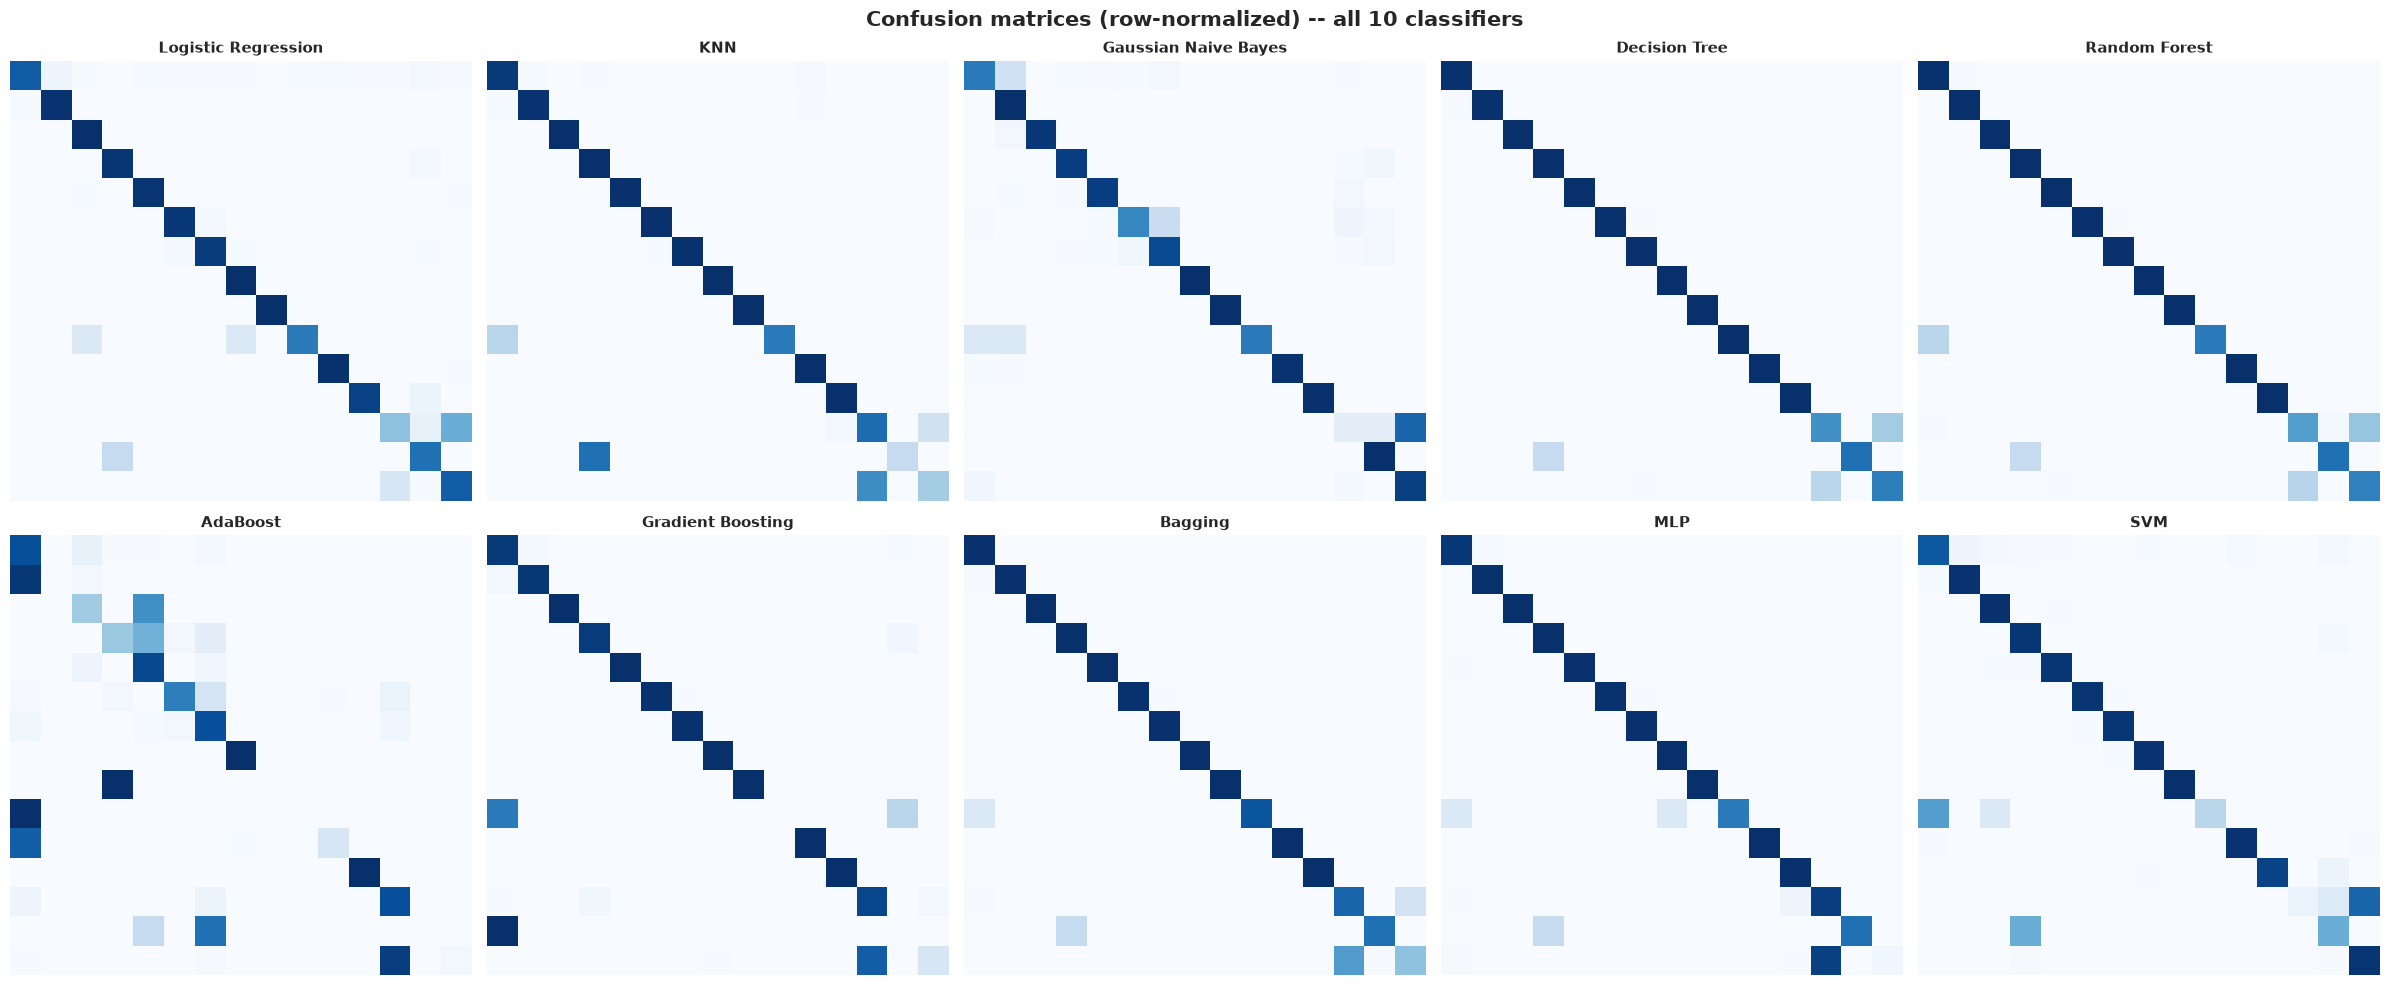

In [12]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for ax, (name, (y_true_m, y_pred_m, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_true_m, y_pred_m)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, cmap="Blues", cbar=False, ax=ax, vmin=0, vmax=1)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Confusion matrices (row-normalized) -- all 10 classifiers", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "classification_confusion_matrices_grid.png"), dpi=150, bbox_inches="tight")
plt.show()


### Detailed view of the best model

Confusion matrix and ROC curves with full labels for whichever model
currently ranks first.

Current best model: Bagging


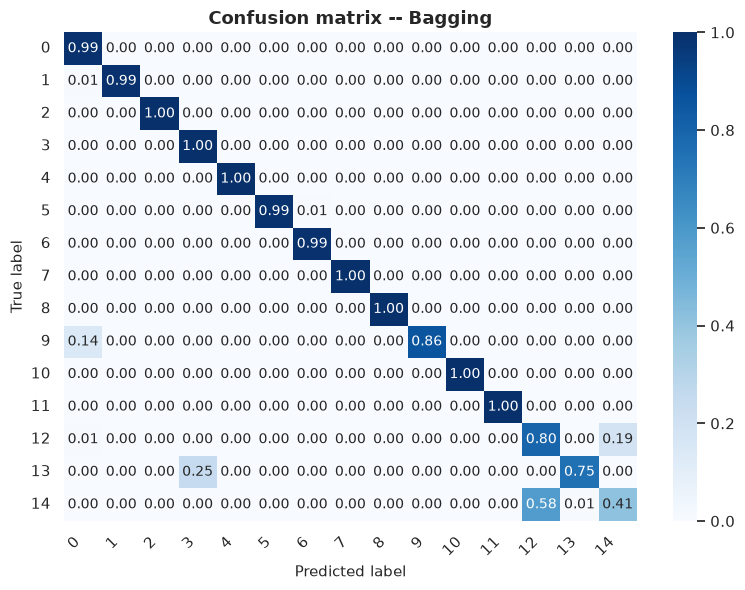

array([[1986,    2,    3,    0,    1,    1,    2,    1,    0,    0,    1,
           0,    1,    0,    2],
       [   3,  387,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0],
       [   2,    0, 1997,    0,    1,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0],
       [   0,    0,    0, 1994,    2,    1,    1,    0,    0,    0,    0,
           0,    0,    2,    0],
       [   1,    0,    1,    2, 1996,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0],
       [   1,    0,    0,    2,    0, 1036,    7,    0,    0,    0,    0,
           0,    0,    0,    0],
       [   2,    0,    0,    0,    0,    3, 1071,    0,    0,    0,    0,
           0,    0,    0,    1],
       [   0,    0,    0,    0,    0,    0,    0, 1186,    0,    0,    0,
           0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    2,    0,    0,
           0,    0,    0,    0],
       [   1,    0,    0,    0,    0,

In [13]:
best_name_so_far = comparison_table.index[0]
y_true_best, y_pred_best, y_proba_best = predictions[best_name_so_far]
best_classes = models[best_name_so_far].classes_ if best_name_so_far in models else svm_model.classes_

print(f"Current best model: {best_name_so_far}")
utils.plot_confusion_matrix(y_true_best, y_pred_best, best_classes, best_name_so_far,
                             save_path=os.path.join(FIGURES_DIR, "best_model_confusion_matrix.png"))


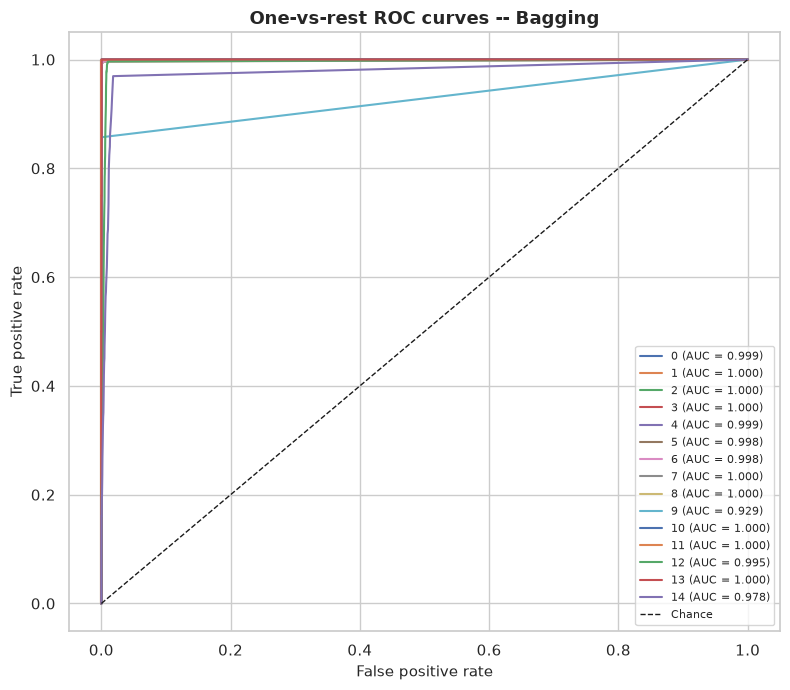

In [14]:
if y_proba_best is not None:
    utils.plot_multiclass_roc(y_true_best, y_proba_best, best_classes, best_name_so_far,
                               save_path=os.path.join(FIGURES_DIR, "best_model_roc_curves.png"))
else:
    print(f"{best_name_so_far} does not expose predict_proba -- no ROC curve to plot.")


## 11. Hyperparameter tuning (Random Forest, SVM, MLP)

`RandomizedSearchCV` is used instead of an exhaustive `GridSearchCV` for
all three -- with SVM and MLP already the slowest models to train once,
searching every combination in a full grid would multiply that cost by
dozens. Randomized search samples a fixed number of combinations instead,
trading a small amount of thoroughness for a large amount of speed.

In [15]:
param_dist_rf = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_dist_rf, n_iter=10, cv=3, scoring="f1_weighted",
    random_state=RANDOM_STATE, n_jobs=-1,
)
with utils.timer("Random Forest tuning"):
    rf_search.fit(X_train_scaled, y_train)

rf_before = utils.evaluate_classifier(models["Random Forest"], X_test_scaled, y_test, "RF (before tuning)", classes=models["Random Forest"].classes_)
rf_after = utils.evaluate_classifier(rf_search.best_estimator_, X_test_scaled, y_test, "RF (tuned)", classes=rf_search.best_estimator_.classes_)

print("Best params:", rf_search.best_params_)
print(f"F1 (weighted) before: {rf_before['F1 (weighted)']:.4f}  ->  after: {rf_after['F1 (weighted)']:.4f}")


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx_

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx_

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx_

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


...

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx_

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx_

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nuraxx_

[Random Forest tuning] completed in 24.90 seconds


Best params: {'n_estimators': 150, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
F1 (weighted) before: 0.9856  ->  after: 0.9869


In [16]:
param_dist_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
}

svm_search = RandomizedSearchCV(
    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions=param_dist_svm, n_iter=8, cv=3, scoring="f1_weighted",
    random_state=RANDOM_STATE, n_jobs=-1,
)
with utils.timer("SVM tuning (on the smaller sub-sample)"):
    svm_search.fit(X_svm_train_scaled, y_svm_train)

svm_before = utils.evaluate_classifier(svm_model, X_test_scaled, y_test, "SVM (before tuning)", classes=svm_model.classes_)
svm_after = utils.evaluate_classifier(svm_search.best_estimator_, X_test_scaled, y_test, "SVM (tuned)", classes=svm_search.best_estimator_.classes_)

print("Best params:", svm_search.best_params_)
print(f"F1 (weighted) before: {svm_before['F1 (weighted)']:.4f}  ->  after: {svm_after['F1 (weighted)']:.4f}")


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_bas

/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[SVM tuning (on the smaller sub-sample)] completed in 64.99 seconds


Best params: {'gamma': 'auto', 'C': 100}
F1 (weighted) before: 0.9451  ->  after: 0.9697


In [17]:
param_dist_mlp = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50), (150, 100)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

mlp_search = RandomizedSearchCV(
    MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
    param_distributions=param_dist_mlp, n_iter=8, cv=3, scoring="f1_weighted",
    random_state=RANDOM_STATE, n_jobs=-1,
)
with utils.timer("MLP tuning"):
    mlp_search.fit(X_train_scaled, y_train)

mlp_before = utils.evaluate_classifier(models["MLP"], X_test_scaled, y_test, "MLP (before tuning)", classes=models["MLP"].classes_)
mlp_after = utils.evaluate_classifier(mlp_search.best_estimator_, X_test_scaled, y_test, "MLP (tuned)", classes=mlp_search.best_estimator_.classes_)

print("Best params:", mlp_search.best_params_)
print(f"F1 (weighted) before: {mlp_before['F1 (weighted)']:.4f}  ->  after: {mlp_after['F1 (weighted)']:.4f}")


[MLP tuning] completed in 19.66 seconds
Best params: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (50,), 'alpha': 0.0001}
F1 (weighted) before: 0.9800  ->  after: 0.9779


## 12. SMOTE: a focused imbalance-handling comparison

Rather than apply SMOTE to all 10 models, we apply it once to the
strongest candidate so far and measure the effect directly -- this makes
the technique's actual impact visible instead of just asserting it helps.
`k_neighbors` is capped to stay valid even if the rarest class in the
training split has very few rows.

In [18]:
candidates = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "SVM (tuned)": svm_search.best_estimator_,
    "MLP (tuned)": mlp_search.best_estimator_,
}
tuned_scores = {
    "Random Forest (tuned)": rf_after["F1 (weighted)"],
    "SVM (tuned)": svm_after["F1 (weighted)"],
    "MLP (tuned)": mlp_after["F1 (weighted)"],
}
best_tuned_name = max(tuned_scores, key=tuned_scores.get)
print(f"Strongest tuned candidate: {best_tuned_name} (F1 weighted = {tuned_scores[best_tuned_name]:.4f})")

min_class_count = pd.Series(y_train).value_counts().min()
k_neighbors = max(1, min(5, min_class_count - 1))
print(f"Smallest class in the training split has {min_class_count} rows -> using k_neighbors={k_neighbors}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Training rows before SMOTE: {len(y_train):,}  ->  after: {len(y_train_smote):,}")


Strongest tuned candidate: Random Forest (tuned) (F1 weighted = 0.9869)
Smallest class in the training split has 9 rows -> using k_neighbors=5


Training rows before SMOTE: 59,120  ->  after: 120,000


In [19]:
from sklearn.base import clone

smote_model = clone(candidates[best_tuned_name])
with utils.timer(f"{best_tuned_name} + SMOTE"):
    smote_model.fit(X_train_smote, y_train_smote)

smote_result = utils.evaluate_classifier(smote_model, X_test_scaled, y_test, f"{best_tuned_name} + SMOTE", classes=smote_model.classes_)

print(f"F1 (weighted) tuned, no SMOTE: {tuned_scores[best_tuned_name]:.4f}")
print(f"F1 (weighted) tuned + SMOTE:   {smote_result['F1 (weighted)']:.4f}")
print(f"F1 (macro)    tuned + SMOTE:   {smote_result['F1 (macro)']:.4f}  (macro is the one to watch for rare-class improvement)")


[Random Forest (tuned) + SMOTE] completed in 3.32 seconds
F1 (weighted) tuned, no SMOTE: 0.9869
F1 (weighted) tuned + SMOTE:   0.9869
F1 (macro)    tuned + SMOTE:   0.9252  (macro is the one to watch for rare-class improvement)


## 13. Selecting the final best model

Compares every candidate produced above (10 baselines, 3 tuned, 1 SMOTE
variant) on weighted F1 and keeps the strongest one as the model that
ships in the app.

In [20]:
final_candidates = {r["Model"]: r["F1 (weighted)"] for r in results}
final_candidates.update({
    "Random Forest (tuned)": rf_after["F1 (weighted)"],
    "SVM (tuned)": svm_after["F1 (weighted)"],
    "MLP (tuned)": mlp_after["F1 (weighted)"],
    f"{best_tuned_name} + SMOTE": smote_result["F1 (weighted)"],
})

final_best_name = max(final_candidates, key=final_candidates.get)
print(f"FINAL BEST MODEL: {final_best_name}  (F1 weighted = {final_candidates[final_best_name]:.4f})")

model_lookup = dict(models)
model_lookup.update({
    "SVM": svm_model,
    "Random Forest (tuned)": rf_search.best_estimator_,
    "SVM (tuned)": svm_search.best_estimator_,
    "MLP (tuned)": mlp_search.best_estimator_,
    f"{best_tuned_name} + SMOTE": smote_model,
})
final_model = model_lookup[final_best_name]


FINAL BEST MODEL: Bagging  (F1 weighted = 0.9873)


## 14. Explainability: feature importance and a worked example

For tree-based models, `feature_importances_` gives a global ranking of
which features drive predictions. We also show one concrete worked
example -- a single prediction with its confidence and top contributing
features -- in the same format the Streamlit app will present.

In [21]:
if hasattr(final_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": final_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature", legend=False, palette="mako")
    plt.title(f"Top 15 feature importances -- {final_best_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "classification_feature_importance.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"{final_best_name} has no feature_importances_ attribute "
          "(this is expected for models like Logistic Regression, KNN, SVM, or Naive Bayes).")


Bagging has no feature_importances_ attribute (this is expected for models like Logistic Regression, KNN, SVM, or Naive Bayes).


### A worked example

The kind of explanation the Streamlit app's detection page will show for
a single uploaded flow.

In [22]:
sample_idx = 0
sample_X = X_test_scaled[sample_idx:sample_idx + 1]
true_label = label_encoder.inverse_transform([y_test[sample_idx]])[0]

pred_encoded = final_model.predict(sample_X)[0]
pred_label = label_encoder.inverse_transform([pred_encoded])[0]

print(f"True label:      {true_label}")
print(f"Predicted label:  {pred_label}")

if hasattr(final_model, "predict_proba"):
    proba = final_model.predict_proba(sample_X)[0]
    confidence = proba.max() * 100
    print(f"Confidence:       {confidence:.1f}%")

if hasattr(final_model, "feature_importances_"):
    top_features = (
        pd.Series(final_model.feature_importances_, index=feature_names)
        .sort_values(ascending=False).head(3)
    )
    print("Top contributing features (global importance):")
    for feat, imp in top_features.items():
        print(f"  - {feat} (importance={imp:.3f})")


True label:      BENIGN
Predicted label:  BENIGN
Confidence:       100.0%


### SHAP (where computationally practical)

`TreeExplainer` is fast enough for tree-based models even on a laptop.
For non-tree models (SVM, KNN, MLP), exact SHAP values are far more
expensive to compute, so this cell only runs for tree-based winners and
explains clearly why otherwise.

In [23]:
import shap

tree_based = ("Forest" in final_best_name or "Tree" in final_best_name
              or "Boosting" in final_best_name or "Bagging" in final_best_name
              or "AdaBoost" in final_best_name)

if tree_based:
    try:
        explainer = shap.TreeExplainer(final_model)
        background = X_test_scaled[:200]  # small sample keeps this fast
        shap_values = explainer.shap_values(background)
        shap.summary_plot(shap_values, background, feature_names=feature_names,
                           class_names=list(CLASS_NAMES), show=False, max_display=12)
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, "shap_summary_classification.png"), dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"SHAP could not run for this model: {e}")
else:
    print(f"{final_best_name} is not tree-based -- exact SHAP is too expensive to run by default here. "
          "The global feature_importances_ / coefficient ranking above is used instead.")


SHAP could not run for this model: Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._bagging.BaggingClassifier'>


## 15. Save the final model and supporting artifacts

Everything the Streamlit app needs to make predictions on new uploads:
the model itself, the scaler (fit on training data), the label encoder
(to turn predictions back into readable attack names), and the exact
feature column order the model expects.

In [24]:
joblib.dump(final_model, os.path.join(MODELS_DIR, "best_model.joblib"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))
joblib.dump(label_encoder, os.path.join(MODELS_DIR, "label_encoder.joblib"))

with open(os.path.join(MODELS_DIR, "feature_names.json"), "w") as f:
    json.dump(feature_names, f, indent=2)

with open(os.path.join(MODELS_DIR, "model_info.json"), "w") as f:
    json.dump({
        "best_model_name": final_best_name,
        "f1_weighted": final_candidates[final_best_name],
        "classes": list(CLASS_NAMES),
    }, f, indent=2)

print(f"Saved best model ({final_best_name}) and supporting artifacts to {MODELS_DIR}")


Saved best model (Bagging) and supporting artifacts to ../models/classification


## 16. Possible mistakes to watch for

- **Comparing tuned models to untuned ones unfairly.** The tuning cells
  above always compare tuned vs. untuned on the *same* test split, so this
  is a fair comparison -- but if you change `WORKING_SAMPLE_SIZE` between
  runs, scores from different runs are no longer directly comparable.
- **SMOTE on the test set.** Never do this -- it was applied to
  `X_train_scaled`/`y_train` only, above. If you extend this notebook,
  keep that boundary.
- **Trusting weighted F1 alone.** A model can score well on weighted F1
  while still performing poorly on rare classes like Heartbleed -- always
  check macro F1 and the per-class confusion matrix rows too.
- **`destination_port` as a shortcut.** Watch whether it dominates the
  feature importance ranking above -- if so, the model may be leaning on
  a port-number lookup table rather than real traffic behavior. Try
  retraining the winning model without that column and compare, as a
  quick robustness check.
